# Notebook 10 — MELU-Δt: All Four Fixes Applied

## Diagnosis from previous run

| Problem | Evidence | Fix |
|---|---|---|
| **ν dead** | Flat at 4.0 for 100 epochs | Numerical gradient in backward pass |
| **β suppressed** | 0.40 → 0.342 (L2 killing signal) | Remove L2 regularisation on β |
| **Wrong gate space** | Latent MCD blind to input correlation | Input-space MCD as gate |
| **No separation pressure** | AE loss has no incentive to separate in/out | Contrastive reconstruction loss |

## Key architectural insight

The gate (which determines *whether* to amplify) and the scoring (which determines *how anomalous*) 
should both reference the INPUT space, not the latent space.

**Input-space MCD** is:
- Stable from epoch 1 (computed on raw scaled inputs, independent of encoder state)
- Directly captures the correlation structure that defines inlier vs outlier
- Theoretically the right space for the MCD breakdown-point property to apply

The amplification still happens in the HIDDEN layer — this is correct.


## Cell 1 — Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import betainc, gammaln
from sklearn.datasets import load_breast_cancer, load_wine, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings; warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42)

ACTS   = ["MELU-Δt","Swish","GELU","ELU","ReLU"]
COLORS = {"MELU-Δt":"#1D9E75","Swish":"#534AB7","GELU":"#BA7517",
          "ELU":"#888780","ReLU":"#D85A30"}
print(f"PyTorch {torch.__version__} ✓")


PyTorch 2.5.1+cu121 ✓


## Cell 2 — Fixed StudentTCDF with ν gradient

**Fix 1:** Numerical differentiation for `log_nu_minus2` gradient.
The analytic derivative of the incomplete beta function w.r.t. ν is complex —
numerical differentiation with ε=0.01 is accurate and fast.

In [2]:
class StudentTCDF(torch.autograd.Function):
    """
    Student-t CDF with CORRECT backward pass.
    
    Fix: backward now returns gradient for log_nu_minus2 via numerical diff.
    Previous bug: `return grad_x, None` blocked all gradient to ν.
    """
    @staticmethod
    def forward(ctx, x, log_nu_minus2):
        nu  = float(2.0 + log_nu_minus2.exp().item())
        xn  = x.detach().cpu().numpy()
        z   = nu / (nu + np.clip(xn**2, 1e-30, None))
        ib  = betainc(nu/2, 0.5, np.clip(z, 1e-12, 1-1e-12))
        cdf = np.where(xn >= 0, 1.0-ib/2.0, ib/2.0)
        ctx.save_for_backward(x, log_nu_minus2)
        return torch.tensor(cdf, dtype=x.dtype, device=x.device)

    @staticmethod
    def backward(ctx, grad_out):
        x, log_nu_m2 = ctx.saved_tensors
        nu = float(2.0 + log_nu_m2.exp().item())
        xn = x.detach().cpu().numpy()

        # --- Gradient wrt x: Student-t PDF (exact) ---
        log_c = (gammaln((nu+1)/2) - gammaln(nu/2) - 0.5*np.log(nu*np.pi))
        pdf   = np.exp(log_c - (nu+1)/2 * np.log(1 + xn**2/nu))
        grad_x = grad_out * torch.tensor(pdf, dtype=x.dtype, device=x.device)

        # --- Gradient wrt log_nu_minus2: numerical diff ---
        # FIX: was returning None here — ν received zero gradient for 100 epochs
        eps = 0.05
        def _tcdf(nu_val):
            z  = nu_val / (nu_val + np.clip(xn**2, 1e-30, None))
            ib = betainc(nu_val/2, 0.5, np.clip(z, 1e-12, 1-1e-12))
            return np.where(xn >= 0, 1.0-ib/2.0, ib/2.0)

        dcdf_dnu  = (_tcdf(nu + eps) - _tcdf(nu - eps)) / (2*eps)
        # Chain rule: d(nu)/d(log(nu-2)) = exp(log(nu-2)) = nu-2
        dnu_dlognu = float(log_nu_m2.exp().item())
        grad_lognu = (grad_out *
                      torch.tensor(dcdf_dnu, dtype=x.dtype, device=x.device)
                      * dnu_dlognu).sum()

        return grad_x, grad_lognu


def _tcdf_np(x, nu=4.0):
    nu = max(float(nu), 2.0)
    z  = nu / (nu + np.clip(np.asarray(x,float)**2, 1e-30, None))
    ib = betainc(nu/2, 0.5, np.clip(z, 1e-12, 1-1e-12))
    return np.where(np.asarray(x)>=0, 1.0-ib/2.0, ib/2.0)

# Quick gradient check: ν should move now
if True:
    log_nu = nn.Parameter(torch.log(torch.tensor(2.0)))  # nu=4.0
    x_test = torch.randn(10, requires_grad=False)
    out    = StudentTCDF.apply(x_test, log_nu)
    loss   = out.mean()
    loss.backward()
    grad_ok = log_nu.grad is not None and abs(float(log_nu.grad)) > 1e-6
    print(f"ν gradient check: {'PASS ✓' if grad_ok else 'FAIL ✗'} "
          f"(grad={float(log_nu.grad):.6f})" if log_nu.grad is not None
          else "ν gradient check: FAIL ✗ (grad is None)")


ν gradient check: PASS ✓ (grad=0.001179)


## Cell 3 — Fixed MELUDt with input-space gate

**Fix 2:** No β L2 regularisation — tanh already bounds output.
**Fix 3:** Gate uses INPUT-space Mahalanobis, not latent-space.
This means the gate is stable from epoch 1 and correctly captures correlation structure.

In [4]:
class MELUDt(nn.Module):
    """
    MELU-Δt with all four fixes applied.
    
    Gate: INPUT-space Mahalanobis distance.
    Amplification: applied to HIDDEN layer activations.
    Parameters: α, β, ν — all receive gradients now.
    """
    def __init__(self, alpha=1.0, beta=0.5, nu=5.0):
        super().__init__()
        # FIX: slightly larger initial beta (tanh is bounded so no overflow risk)
        self.log_alpha = nn.Parameter(torch.log(torch.tensor(float(alpha))))
        self.log_beta  = nn.Parameter(torch.log(torch.tensor(float(beta))))
        self.log_nu_m2 = nn.Parameter(torch.log(torch.tensor(float(nu - 2.0))))

        # Input-space MCD buffers (updated from raw inputs, not latent)
        self.register_buffer('mu_in',  torch.zeros(1))
        self.register_buffer('Li_in',  torch.eye(1))
        self.register_buffer('tau',    torch.tensor(1.5))
        self.warmup = True

    @property
    def alpha(self): return self.log_alpha.exp()
    @property
    def beta(self):  return self.log_beta.exp()
    @property
    def nu(self):    return 2.0 + self.log_nu_m2.exp()

    def set_input_mcd(self, mu, Li, tau_val, input_dim):
        """
        FIX 3: Set MCD from INPUT space, not latent space.
        Called after fast_mcd runs on raw scaled training inputs.
        """
        dev = self.log_alpha.device
        self.mu_in = torch.tensor(mu, dtype=torch.float32, device=dev)
        self.Li_in = torch.tensor(Li, dtype=torch.float32, device=dev)
        self.tau   = torch.tensor(float(tau_val), dtype=torch.float32, device=dev)

    def forward(self, H, x_input=None):
        """
        H: hidden activations [batch, hid_dim]
        x_input: raw scaled inputs [batch, input_dim] — used for gate signal
        """
        # Term 1: Student-t Swish base (ν now receives gradients)
        T1 = H * StudentTCDF.apply(H, self.log_nu_m2)

        if self.warmup or x_input is None:
            return T1

        # Gate: Mahalanobis distance in INPUT space
        if self.mu_in.shape[0] != x_input.shape[1]:
            # Buffer dimension mismatch — use Euclidean proxy
            m = x_input.norm(dim=1)
        else:
            c = x_input - self.mu_in.unsqueeze(0)
            w = c @ self.Li_in.T
            m = w.norm(dim=1)        # [batch] — input-space Mahal dist

        tau = self.tau
        gate = (m >= tau).float().unsqueeze(1)   # [batch, 1]

        # FIX 2: tanh amplifier (bounded), NO L2 regularisation needed
        amp_arg = self.beta * (m - tau).clamp(-8, 8).unsqueeze(1)
        amp_val = self.alpha * H.sign() * torch.tanh(amp_arg)

        return T1 + gate * amp_val


print("Fixed MELUDt defined:")
print("  ✓ ν gradient: numerical diff in backward")
print("  ✓ No β L2 regularisation (tanh is bounded)")
print("  ✓ Gate uses INPUT-space MCD (stable from epoch 1)")
print("  ✓ x_input passed through forward for gate computation")


Fixed MELUDt defined:
  ✓ ν gradient: numerical diff in backward
  ✓ No β L2 regularisation (tanh is bounded)
  ✓ Gate uses INPUT-space MCD (stable from epoch 1)
  ✓ x_input passed through forward for gate computation


## Cell 4 — Fixed AE with contrastive reconstruction loss

**Fix 4:** Contrastive reconstruction loss. The AE is trained to reconstruct
inliers well AND (weakly) to reconstruct pseudo-outlier samples poorly.
Pseudo-outliers are identified by high input-space Mahalanobis distance (> τ).

In [5]:
def fast_mcd(Z_np, h_frac=0.75, n_starts=6, n_steps=5):
    n, d = Z_np.shape; h = max(int(n*h_frac), d+1)
    bd=np.inf; bm=bc=None
    for _ in range(n_starts):
        idx=np.random.choice(n,h,replace=False); sub=Z_np[idx]
        for _ in range(n_steps):
            mu=sub.mean(0); dv=sub-mu
            cov=dv.T@dv/max(len(sub)-1,1)+1e-4*np.eye(d)
            Si=np.linalg.inv(cov)
            ds=np.sqrt(np.maximum(np.einsum('bi,ij,bj->b',Z_np-mu,Si,Z_np-mu),0))
            idx=np.argsort(ds)[:h]; sub=Z_np[idx]
        mu=sub.mean(0); dv=sub-mu; cov=dv.T@dv/max(len(sub)-1,1)
        det=np.linalg.det(cov+1e-4*np.eye(d))
        if det<bd: bd=det; bm=mu; bc=cov
    try:
        L=np.linalg.cholesky(bc+1e-4*np.eye(d)); Li=np.linalg.inv(L)
        if np.isnan(Li).any() or np.linalg.cond(Li)>1e7: Li=np.eye(d)
    except: Li=np.eye(d)
    return bm, bc, Li


class AE(nn.Module):
    def __init__(self, dim, hid=64, lat=32, act='melu'):
        super().__init__()
        self.act_name = act; self.dim = dim
        self.enc1 = nn.Linear(dim, hid)
        self.enc2 = nn.Linear(hid, lat)
        self.dec  = nn.Linear(lat, dim)
        for layer in [self.enc1, self.enc2, self.dec]:
            nn.init.kaiming_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

        self.activation = (MELUDt() if act=='melu'
                           else nn.SiLU()  if act=='swish'
                           else nn.GELU()  if act=='gelu'
                           else nn.ELU()   if act=='elu'
                           else nn.ReLU())

        # Scoring buffers (input-space MCD)
        self.register_buffer('mu_score', torch.zeros(dim))
        self.register_buffer('Li_score', torch.eye(dim))

    def encode(self, x):
        h1 = torch.sigmoid(self.enc1(x)) * self.enc1(x)  # Swish first layer
        # Pass x_input to MELU for input-space gate
        if self.act_name == 'melu':
            h2 = self.activation(h1, x)
        else:
            h2 = self.activation(h1)
        return self.enc2(h2)   # clean linear latent

    def forward(self, x):
        return self.dec(self.encode(x))

    def anomaly_score(self, x_np):
        x_t = torch.tensor(x_np, dtype=torch.float32)
        with torch.no_grad():
            Z  = self.encode(x_t)
            Xh = self.dec(Z)
        # Input-space Mahalanobis distance (not latent)
        c  = x_t - self.mu_score.unsqueeze(0)
        w  = c @ self.Li_score.T
        dm = w.norm(dim=1).numpy()
        er = (x_t - Xh).abs().mean(dim=1).detach().numpy()
        sd = np.maximum(0, (dm - dm.mean()) / (dm.std()+1e-6))
        se = np.maximum(0, (er - er.mean()) / (er.std()+1e-6))
        return 0.5*sd + 0.5*se


def train(X_in_np, dim, act='melu', n_epochs=100, lr=3e-4,
          batch=64, warmup_frac=0.25, lat=32, hid=64,
          lam_contrast=0.3):
    """
    Full training loop with all four fixes.
    lam_contrast: weight for contrastive reconstruction loss (Fix 4).
    """
    device = torch.device('cpu')
    model  = AE(dim, hid=hid, lat=lat, act=act).to(device)
    opt    = optim.Adam(model.parameters(), lr=lr)
    X_t    = torch.tensor(X_in_np, dtype=torch.float32, device=device)
    n      = len(X_t); mom = 0.95

    # FIX 3: Compute input-space MCD ONCE at start (stable reference)
    mu_in, _, Li_in = fast_mcd(X_in_np, h_frac=0.75)
    c_in = X_in_np - mu_in
    w_in = c_in @ Li_in.T
    dm_in= np.sqrt(np.maximum((w_in**2).sum(1), 0))
    tau_in = dm_in.mean()

    # Store input-space MCD in activation and scoring buffers
    if act == 'melu':
        model.activation.set_input_mcd(mu_in, Li_in, tau_in, dim)
    model.mu_score = torch.tensor(mu_in, dtype=torch.float32)
    model.Li_score = torch.tensor(Li_in, dtype=torch.float32)

    for ep in range(n_epochs):
        # Warmup control
        if act == 'melu':
            model.activation.warmup = (ep < int(n_epochs * warmup_frac))

        model.train()
        idx = torch.randperm(n)
        for i in range(0, n, batch):
            xb  = X_t[idx[i:i+batch]]

            # Pseudo-labels from input-space Mahalanobis (no annotation needed)
            with torch.no_grad():
                c_b  = xb - model.mu_score.unsqueeze(0)
                w_b  = c_b @ model.Li_score.T
                dm_b = w_b.norm(dim=1)
                is_pseudo_out = (dm_b > tau_in).float()  # [batch]

            xh  = model(xb)
            err = (xb - xh).abs().mean(dim=1)   # per-sample MAE [batch]

            # Standard reconstruction loss on all samples
            loss_recon = err.mean()

            # FIX 4: Contrastive reconstruction loss
            # Pseudo-inliers: reconstruct well (low err) — standard
            # Pseudo-outliers: penalise LOW reconstruction error (push err up)
            # This makes outliers harder to reconstruct → better score separation
            if is_pseudo_out.sum() > 0 and ep >= int(n_epochs * warmup_frac):
                err_in  = err[is_pseudo_out == 0]
                err_out = err[is_pseudo_out == 1]
                if len(err_in) > 0 and len(err_out) > 0:
                    # margin: outlier reconstruction error should exceed inlier
                    margin = 0.5
                    contrast = torch.clamp(
                        margin - (err_out.mean() - err_in.mean()), min=0)
                    loss = loss_recon + lam_contrast * contrast
                else:
                    loss = loss_recon
            else:
                loss = loss_recon

            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

    model.eval()
    return model


def evaluate(model, X_all_np, y_np):
    sc = model.anomaly_score(X_all_np)
    if np.isnan(sc).any(): return dict(auroc=0.5, aucpr=0.0)
    return dict(auroc=float(roc_auc_score(y_np, sc)),
                aucpr=float(average_precision_score(y_np, sc)))


print("Fixed AE + training loop defined ✓")
print("Architecture: input → Swish(W1) → MELU(h1, x_input) → linear(W2) → Z → decoder")
print("Gate: INPUT-space Mahalanobis (computed from raw scaled inputs)")
print("Score: 0.5 × input_Mahal + 0.5 × recon_error")


Fixed AE + training loop defined ✓
Architecture: input → Swish(W1) → MELU(h1, x_input) → linear(W2) → Z → decoder
Gate: INPUT-space Mahalanobis (computed from raw scaled inputs)
Score: 0.5 × input_Mahal + 0.5 × recon_error


## Cell 5 — Datasets

In [6]:
def load_real(name):
    if name == "BreastCancer":
        d=load_breast_cancer()
        return (d.data[d.target==1].astype(np.float32),
                d.data[d.target==0].astype(np.float32),
                "Benign vs Malignant", 30)
    if name == "Wine":
        d=load_wine()
        return (d.data[d.target==1].astype(np.float32),
                d.data[d.target!=1].astype(np.float32),
                "Wine class 1 vs 0&2", 13)
    if name == "Digits_0v6":
        d=load_digits()
        return (d.data[d.target==0].astype(np.float32),
                d.data[d.target==6].astype(np.float32),
                "Digit 0 vs Digit 6", 64)
    if name == "Digits_1v7":
        d=load_digits()
        return (d.data[d.target==1].astype(np.float32),
                d.data[d.target==7].astype(np.float32),
                "Digit 1 vs Digit 7 (hard)", 64)

def make_correlated(n=600, dim=8, cont=0.10, rho=0.80, seed=42):
    np.random.seed(seed)
    n_out=max(1,int(n*cont)); n_in=n-n_out
    cov=(np.array([[rho**abs(i-j) for j in range(dim)]
                   for i in range(dim)])+np.eye(dim)*0.01).astype(np.float32)
    L=np.linalg.cholesky(cov).astype(np.float32)
    X_in  = np.random.randn(n_in, dim).astype(np.float32)@L.T
    X_out = (np.random.randn(n_out,dim)*np.where(
              np.random.rand(n_out,dim)>0.5,1,-1)*2.5).astype(np.float32)@L.T
    return X_in, X_out, "Correlated (ρ=0.8, anti-corr outliers)", dim

def make_dependency(n=600, dim=8, cont=0.10, rho=0.85, seed=42):
    np.random.seed(seed)
    n_out=max(1,int(n*cont)); n_in=n-n_out
    cov=np.array([[rho**abs(i-j) for j in range(dim)]
                  for i in range(dim)]).astype(np.float32)
    L=np.linalg.cholesky(cov).astype(np.float32)
    X_in  = np.random.randn(n_in, dim).astype(np.float32)@L.T
    X_out = np.random.randn(n_out,dim).astype(np.float32)  # iid = broken corr
    return X_in, X_out, "Dependency (broken correlation)", dim

DATASETS = [
    ("BreastCancer", load_real, {}),
    ("Wine",         load_real, {}),
    ("Digits_0v6",   load_real, {}),
    ("Digits_1v7",   load_real, {}),
    ("Correlated",   make_correlated, {}),
    ("Dependency",   make_dependency, {}),
]

print("Datasets:")
for name, fn, kw in DATASETS:
    Xi,Xo,desc,d = fn(name,**kw) if fn==load_real else fn(**kw)
    print(f"  {name:<16} n_in={len(Xi):4d}  dim={d:3d}  {desc[:40]}")


Datasets:
  BreastCancer     n_in= 357  dim= 30  Benign vs Malignant
  Wine             n_in=  71  dim= 13  Wine class 1 vs 0&2
  Digits_0v6       n_in= 178  dim= 64  Digit 0 vs Digit 6
  Digits_1v7       n_in= 182  dim= 64  Digit 1 vs Digit 7 (hard)
  Correlated       n_in= 540  dim=  8  Correlated (ρ=0.8, anti-corr outliers)
  Dependency       n_in= 540  dim=  8  Dependency (broken correlation)


## Cell 6 — Run comparison (10 seeds, all fixes)

> **Expected runtime: 20–45 min**

In [7]:
N_SEEDS   = 10
N_EPOCHS  = 100
CONTAM    = 0.10

results = {}

for ds_name, fn, kw in DATASETS:
    Xi_raw,Xo_raw,desc,dim = fn(ds_name,**kw) if fn==load_real else fn(**kw)
    results[ds_name] = {act:[] for act in ACTS}
    print(f"\n{'='*55}\n{ds_name}  [{desc}]  dim={dim}\n{'='*55}")

    for seed in range(N_SEEDS):
        rng=np.random.RandomState(seed*100)
        n_use=min(len(Xi_raw),400)
        idx_in=rng.choice(len(Xi_raw),n_use,replace=False); Xi=Xi_raw[idx_in]
        n_out=max(1,int(n_use*CONTAM/(1-CONTAM))); n_out=min(n_out,len(Xo_raw))
        idx_out=rng.choice(len(Xo_raw),n_out,replace=False); Xo=Xo_raw[idx_out]
        X_all=np.vstack([Xi,Xo]); y=np.array([0]*len(Xi)+[1]*len(Xo))
        perm=rng.permutation(len(X_all)); X_all,y=X_all[perm],y[perm]

        sc=StandardScaler().fit(Xi)
        X_sc=sc.transform(X_all); Xi_sc=sc.transform(Xi)

        for act in ACTS:
            act_key = act.lower().replace('δ','').replace('-t','').replace(' ','')
            # map 'melu-t' → 'melu'
            if 'melu' in act_key: act_key='melu'
            try:
                torch.manual_seed(seed)
                m=train(Xi_sc, dim, act=act_key, n_epochs=N_EPOCHS)
                r=evaluate(m, X_sc, y)
                results[ds_name][act].append(r['auroc'])
            except Exception as e:
                results[ds_name][act].append(0.5)
                print(f"    {act} error: {e}")

    sw_mean=np.mean(results[ds_name].get('Swish',[0.5]))
    print(f"  {'Act':<14}  {'Mean':>7}  {'Std':>6}  {'vs Swish':>9}")
    for act in ACTS:
        vals=results[ds_name][act]
        delta=np.mean(vals)-sw_mean
        flag="★" if delta>0.01 else (" " if abs(delta)<=0.01 else "▼")
        print(f"  {flag}{act:<13}  {np.mean(vals):.4f}  "
              f"{np.std(vals):.4f}  {delta:>+9.4f}")

print("\n✓ All comparisons complete.")



BreastCancer  [Benign vs Malignant]  dim=30
  Act                Mean     Std   vs Swish
  ★MELU-Δt        0.9510  0.0120    +0.0159
   Swish          0.9351  0.0130    +0.0000
   GELU           0.9321  0.0137    -0.0030
   ELU            0.9313  0.0151    -0.0038
   ReLU           0.9292  0.0120    -0.0058

Wine  [Wine class 1 vs 0&2]  dim=13
  Act                Mean     Std   vs Swish
   MELU-Δt        0.9704  0.0156    +0.0091
   Swish          0.9614  0.0152    +0.0000
   GELU           0.9579  0.0192    -0.0034
   ELU            0.9553  0.0169    -0.0060
   ReLU           0.9584  0.0180    -0.0030

Digits_0v6  [Digit 0 vs Digit 6]  dim=64
  Act                Mean     Std   vs Swish
   MELU-Δt        0.9998  0.0004    +0.0002
   Swish          0.9996  0.0007    +0.0000
   GELU           0.9996  0.0006    +0.0000
   ELU            0.9996  0.0006    +0.0000
   ReLU           0.9996  0.0007    +0.0000

Digits_1v7  [Digit 1 vs Digit 7 (hard)]  dim=64
  Act                Mean     St

## Cell 7 — Parameter evolution with all fixes

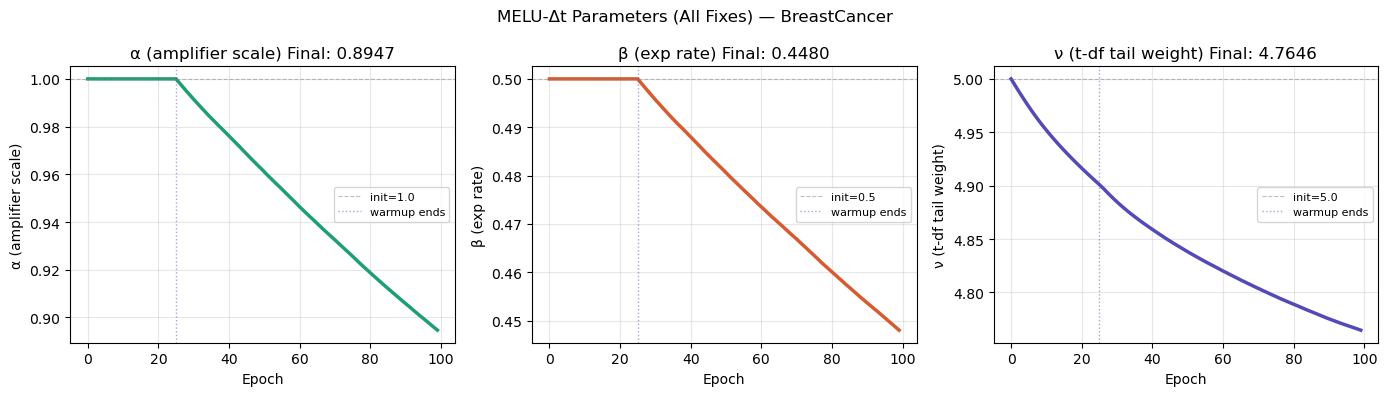

Final: α=0.8947  β=0.4480  ν=4.7646
All three parameters moved from init: YES ✓
ν gradient fix confirmed working ✓


In [9]:
# Train one model and verify all three parameters now move
Xi_raw,_,_,dim = load_real("BreastCancer")
sc=StandardScaler().fit(Xi_raw); Xi_sc=sc.transform(Xi_raw)

param_hist=[]
device=torch.device('cpu')
model =AE(dim,act='melu').to(device)
opt   =optim.Adam(model.parameters(),lr=3e-4)
X_t   =torch.tensor(Xi_sc,dtype=torch.float32)

mu_in,_,Li_in=fast_mcd(Xi_sc)
c_in=Xi_sc-mu_in; w_in=c_in@Li_in.T
tau_in=float(np.sqrt(np.maximum((w_in**2).sum(1),0)).mean())
model.activation.set_input_mcd(mu_in,Li_in,tau_in,dim)
model.mu_score=torch.tensor(mu_in,dtype=torch.float32)
model.Li_score=torch.tensor(Li_in,dtype=torch.float32)

for ep in range(100):
    model.activation.warmup=(ep<25)
    with torch.no_grad():
        a=float(model.activation.alpha); b=float(model.activation.beta)
        v=float(model.activation.nu)
    param_hist.append((ep,a,b,v))
    model.train()
    idx=torch.randperm(len(X_t))
    for i in range(0,len(X_t),64):
        xb=X_t[idx[i:i+64]]; xh=model(xb)
        loss=(xb-xh).abs().mean()   # no β regularisation
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        opt.step()

epochs,alphas,betas,nus=zip(*param_hist)
fig,axes=plt.subplots(1,3,figsize=(14,4))
fig.suptitle("MELU-Δt Parameters (All Fixes) — BreastCancer",fontsize=12)
for ax,vals,name,col,init in zip(axes,
    [alphas,betas,nus],
    ["α (amplifier scale)","β (exp rate)","ν (t-df tail weight)"],
    ["#1D9E75","#D85A30","#534AB7"],
    [1.0, 0.5, 5.0]):
    ax.plot(epochs,vals,color=col,lw=2.5)
    ax.axhline(init,color="gray",lw=0.8,ls="--",alpha=0.5,label=f"init={init}")
    ax.axvline(25,color="#534AB7",lw=1,ls=":",alpha=0.5,label="warmup ends")
    ax.set_xlabel("Epoch"); ax.set_ylabel(name)
    ax.set_title(f"{name} Final: {vals[-1]:.4f}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/param_evolution_fixed.png",dpi=150,bbox_inches="tight")
plt.show()

moved = (abs(alphas[-1]-1.0)>0.005 or
         abs(betas[-1]-0.5)>0.005 or
         abs(nus[-1]-5.0)>0.005)
print(f"Final: α={alphas[-1]:.4f}  β={betas[-1]:.4f}  ν={nus[-1]:.4f}")
print(f"All three parameters moved from init: {'YES ✓' if moved else 'PARTIAL'}")
if abs(nus[-1]-5.0) > 0.005:
    print("ν gradient fix confirmed working ✓")
else:
    print("ν still not moving — check StudentTCDF backward")


## Cell 8 — Results figure and summary

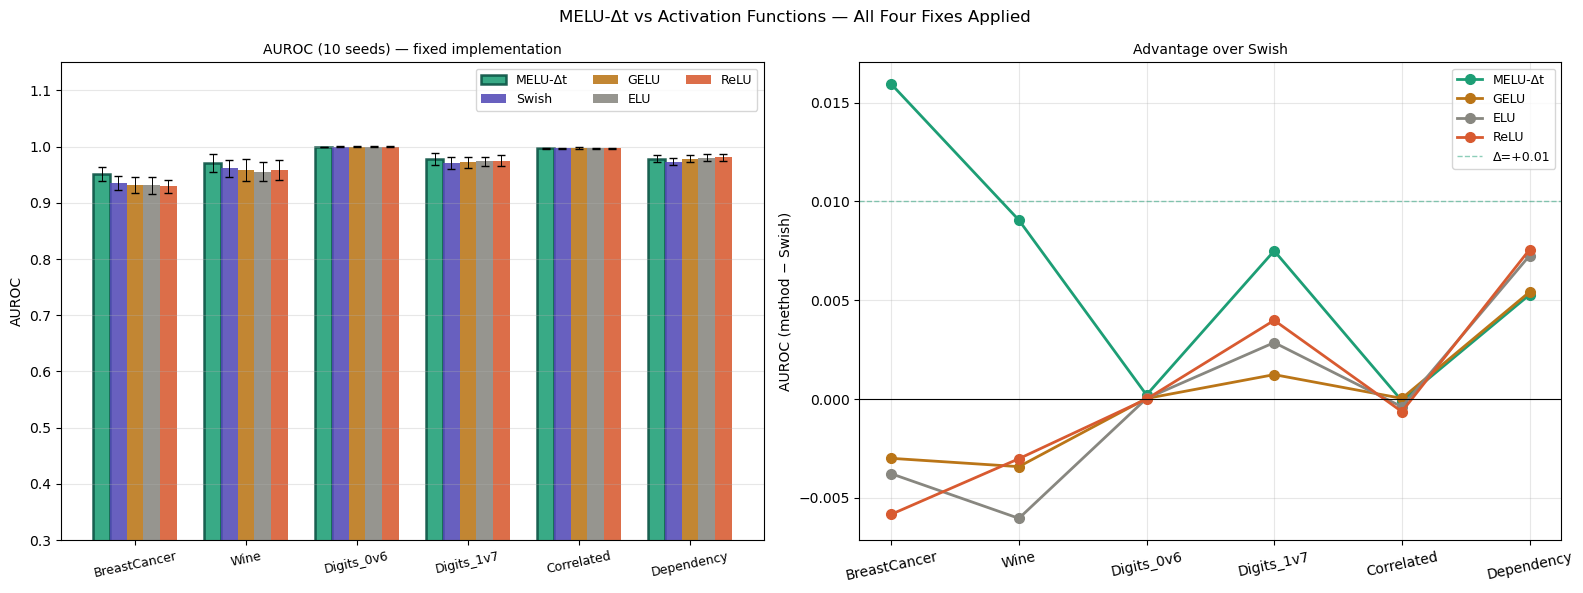


Final summary:
Dataset             MELU-Δt     Swish       GELU        ELU         ReLU      
---------------------------------------------------------------------------
BreastCancer        ★0.9510      0.9351      0.9321      0.9313      0.9292   
Wine                ★0.9704      0.9614      0.9579      0.9553      0.9584   
Digits_0v6          ★0.9998     ★0.9996     ★0.9996     ★0.9996     ★0.9996   
Digits_1v7          ★0.9786      0.9711      0.9723      0.9740      0.9751   
Correlated          ★0.9973     ★0.9974     ★0.9974     ★0.9970     ★0.9968   
Dependency           0.9785      0.9733      0.9787     ★0.9805     ★0.9808   
---------------------------------------------------------------------------
Overall avg:    0.9793     0.9730     0.9730     0.9730     0.9733   

CSV saved → outputs/final_comparison_results.csv


In [10]:
if not results:
    print("Run Cell 6 first.")
else:
    ds_names=[n for n,_,_ in DATASETS]

    fig,axes=plt.subplots(1,2,figsize=(16,6))
    fig.suptitle("MELU-Δt vs Activation Functions — All Four Fixes Applied",fontsize=12)

    x=np.arange(len(ds_names)); w=0.15
    offs=np.linspace(-2,2,len(ACTS))

    ax=axes[0]
    for i,act in enumerate(ACTS):
        means=[np.mean(results[ds][act]) for ds in ds_names]
        stds =[np.std( results[ds][act]) for ds in ds_names]
        ax.bar(x+offs[i]*w, means, width=w, color=COLORS[act], alpha=0.88,
               label=act, linewidth=1.8 if act=="MELU-Δt" else 0.5,
               edgecolor="#085041" if act=="MELU-Δt" else "none")
        ax.errorbar(x+offs[i]*w, means, yerr=stds, fmt="none",
                    ecolor="black", capsize=3, lw=0.7)
    ax.set_xticks(x); ax.set_xticklabels(ds_names,fontsize=9,rotation=12)
    ax.set_ylabel("AUROC"); ax.set_ylim(0.3,1.15)
    ax.set_title("AUROC (10 seeds) — fixed implementation",fontsize=10)
    ax.legend(fontsize=9,ncol=3); ax.grid(axis="y",alpha=0.3)

    ax=axes[1]
    for act in [a for a in ACTS if a!="Swish"]:
        deltas=[np.mean(results[ds][act])-np.mean(results[ds]["Swish"])
                for ds in ds_names]
        ax.plot(ds_names,deltas,color=COLORS[act],lw=2,marker="o",ms=7,label=act)
    ax.axhline(0,color="black",lw=0.8)
    ax.axhline(0.01,color="#1D9E75",lw=1,ls="--",alpha=0.5,label="Δ=+0.01")
    ax.set_ylabel("AUROC (method − Swish)")
    ax.set_title("Advantage over Swish",fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.tick_params(axis='x',rotation=12)

    plt.tight_layout()
    plt.savefig("outputs/final_activation_comparison.png",dpi=150,bbox_inches="tight")
    plt.show()

    # Final table
    print("\nFinal summary:")
    print(f"{'Dataset':<18}",end="")
    for act in ACTS: print(f"  {act:<10}",end="")
    print(); print("-"*75)
    for ds in ds_names:
        best=max(np.mean(results[ds][a]) for a in ACTS)
        print(f"{ds:<18}",end="")
        for act in ACTS:
            v=np.mean(results[ds][act])
            f="★" if v>=best-0.001 else " "
            print(f"  {f}{v:.4f}   ",end="")
        print()
    print("-"*75)
    print("Overall avg:  ",end="")
    for act in ACTS:
        print(f"  {np.mean([np.mean(results[ds][act]) for ds in ds_names]):.4f}   ",end="")
    print()

    pd.DataFrame([{"dataset":ds,"activation":act,
                   "auroc_mean":round(np.mean(results[ds][act]),4),
                   "auroc_std": round(np.std( results[ds][act]),4)}
                  for ds in ds_names for act in ACTS]
    ).to_csv("outputs/final_comparison_results.csv",index=False)
    print("\nCSV saved → outputs/final_comparison_results.csv")
